SIGNAL VISUALIZATION STARTED

Processed data directory found:
E:\Major_Project\AI-Based-Intelligent-RF-Spectrum-Signal-Identification-System-main\data\processed

Loading processed data...
Processed data loaded successfully!

X_train shape: (154000, 2, 128)
y_train shape: (154000,)
SNR shape: (154000,)

Modulation Classes:
0: 8PSK
1: AM-DSB
2: AM-SSB
3: BPSK
4: CPFSK
5: GFSK
6: PAM4
7: QAM16
8: QAM64
9: QPSK
10: WBFM

SELECTED SIGNAL
Sample Index: 0
Modulation Type: QPSK
SNR: 6 dB
Signal Shape: (2, 128)


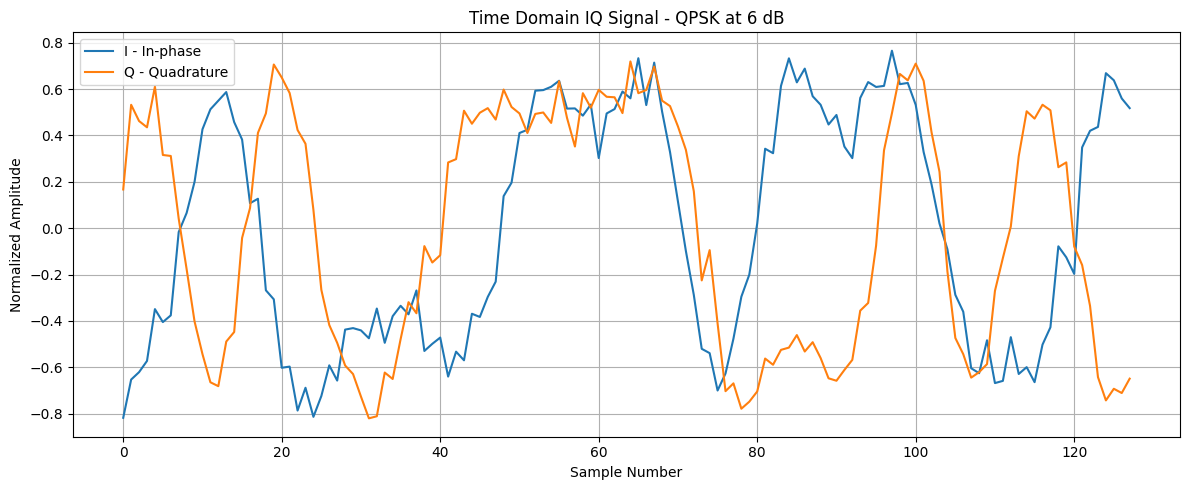

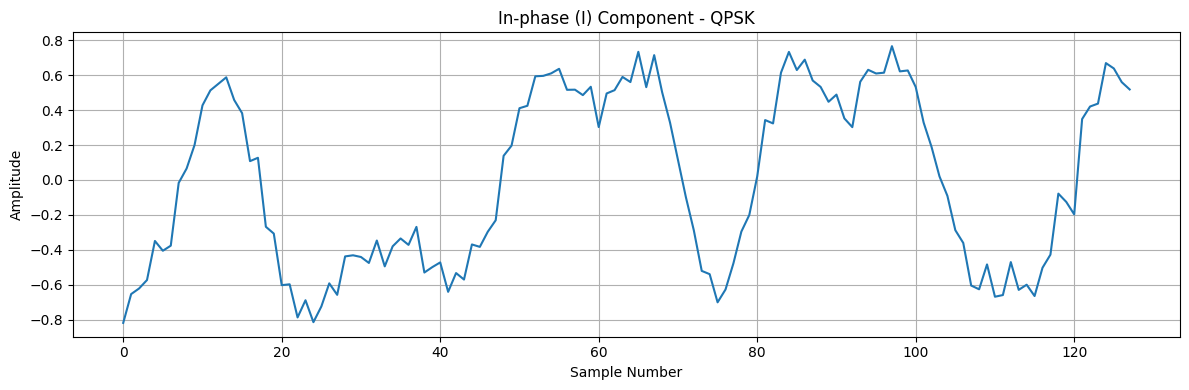

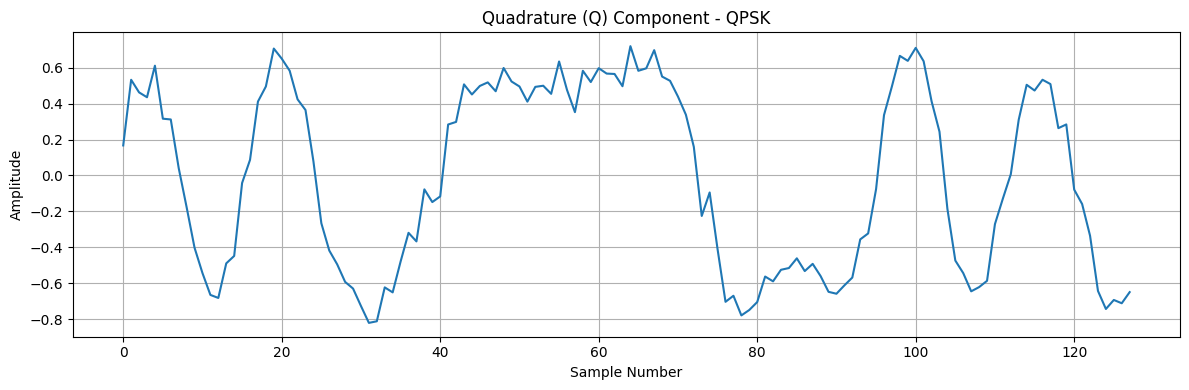

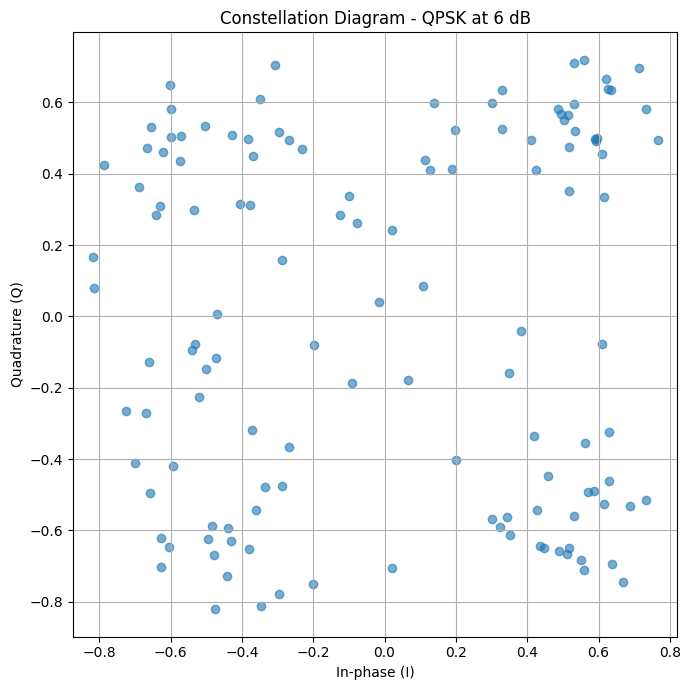


Complex Signal Shape: (128,)


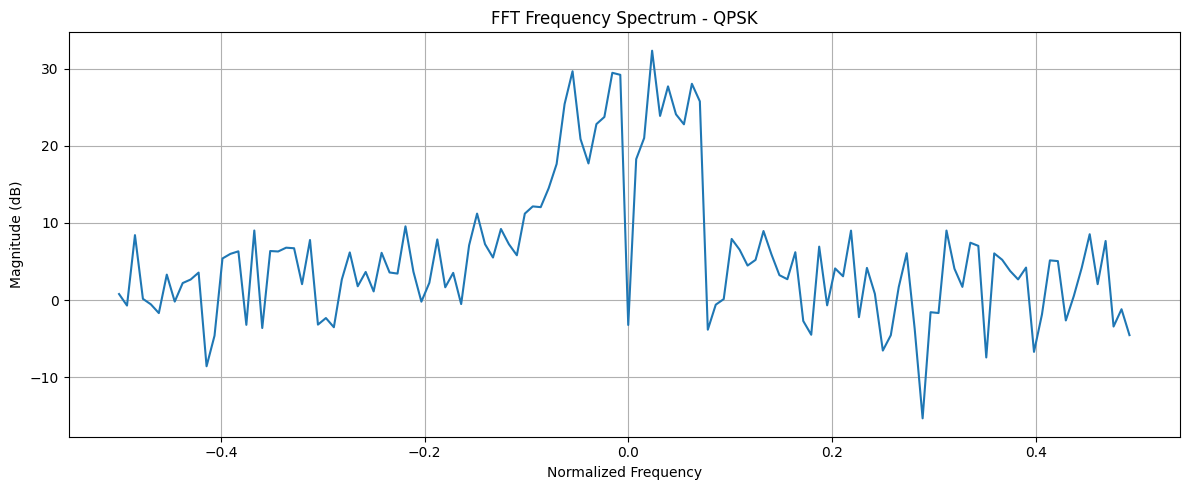

C:\Users\Sujan GS\AppData\Local\Temp\ipykernel_8984\506624799.py:251: UserWarning: Input data is complex, switching to return_onesided=False
  frequencies, times, Sxx = signal.spectrogram(


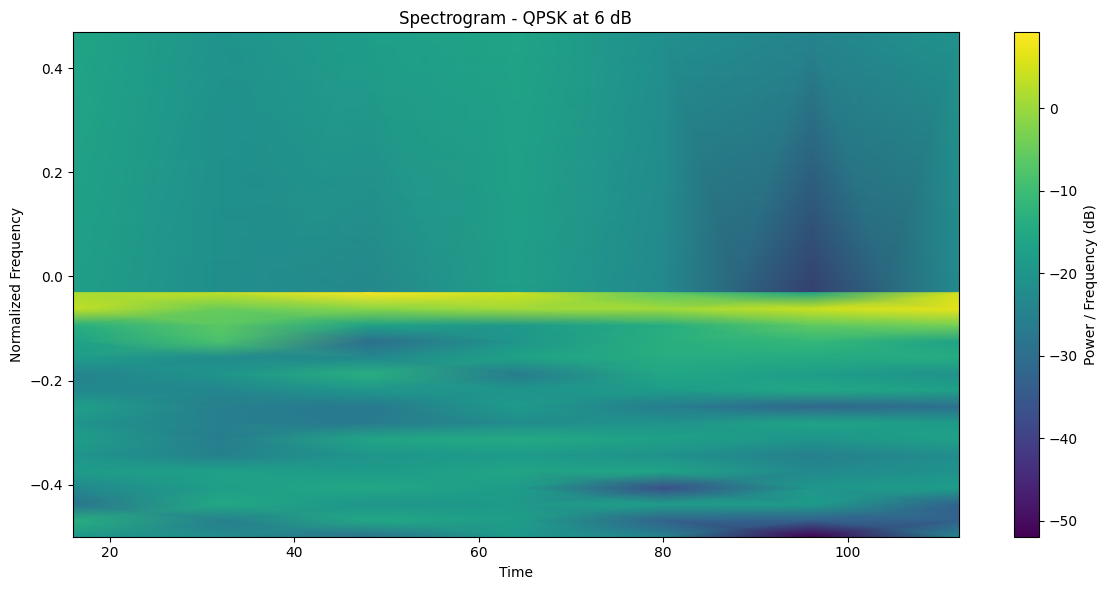


MODULATION COMPARISON
Displaying BPSK at SNR 10 dB


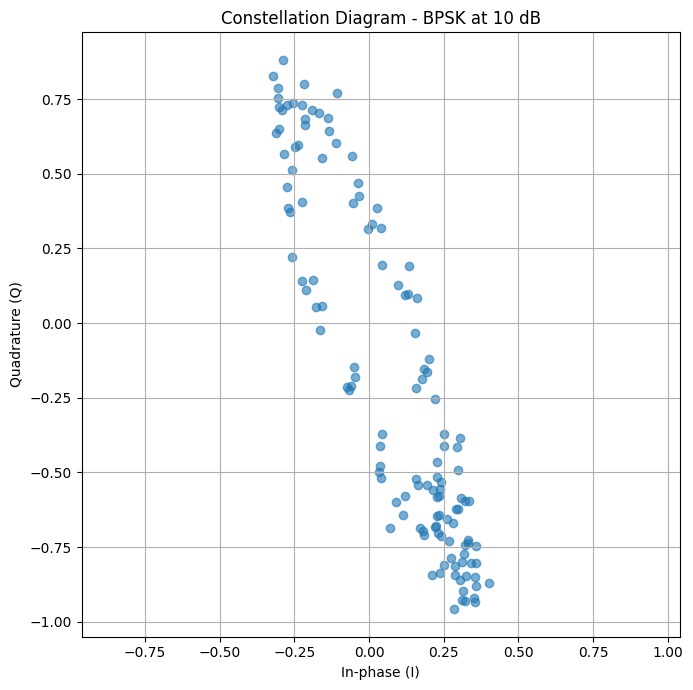

Displaying QPSK at SNR 10 dB


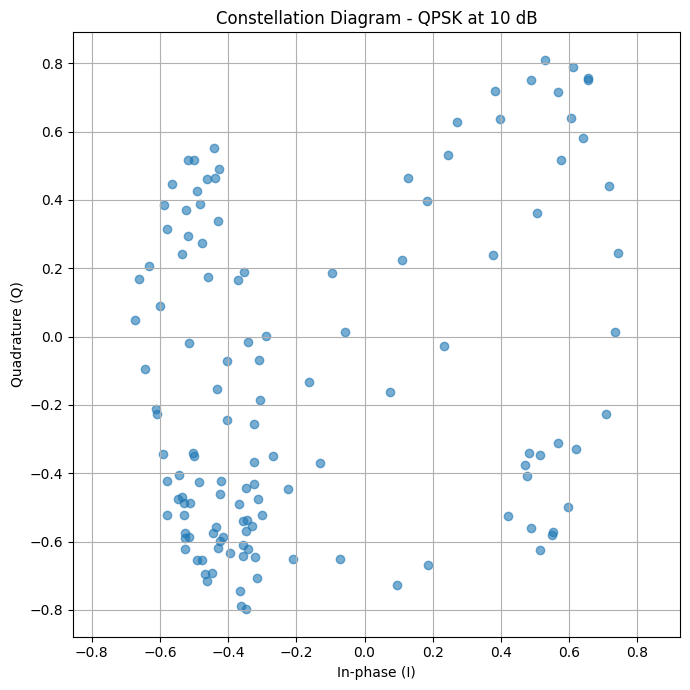

Displaying 8PSK at SNR 10 dB


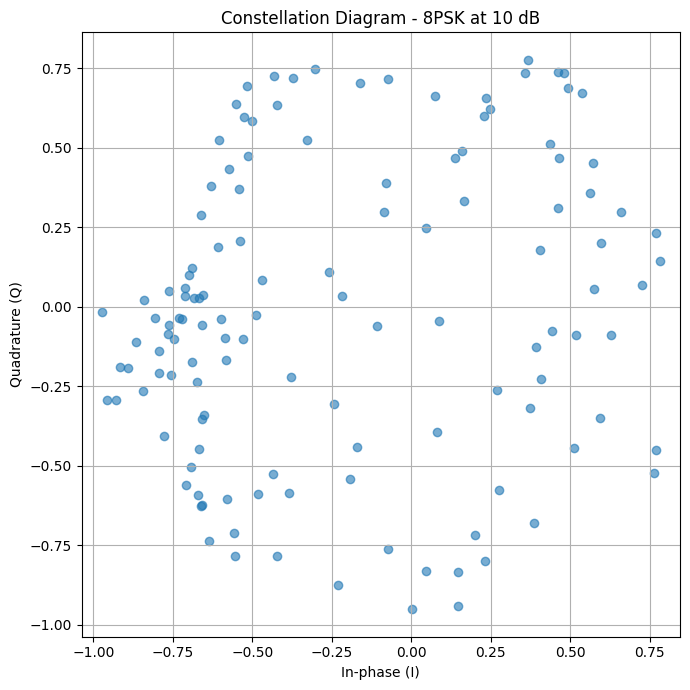

Displaying QAM16 at SNR 10 dB


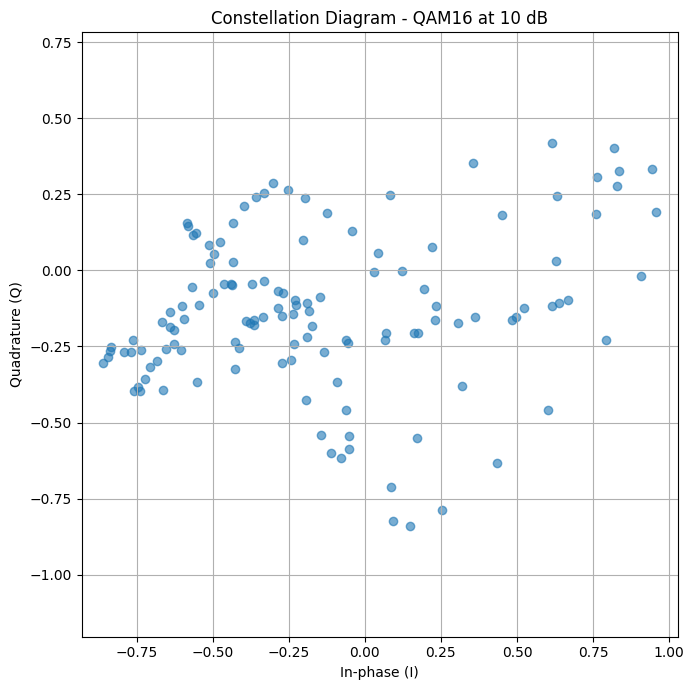

Displaying QAM64 at SNR 10 dB


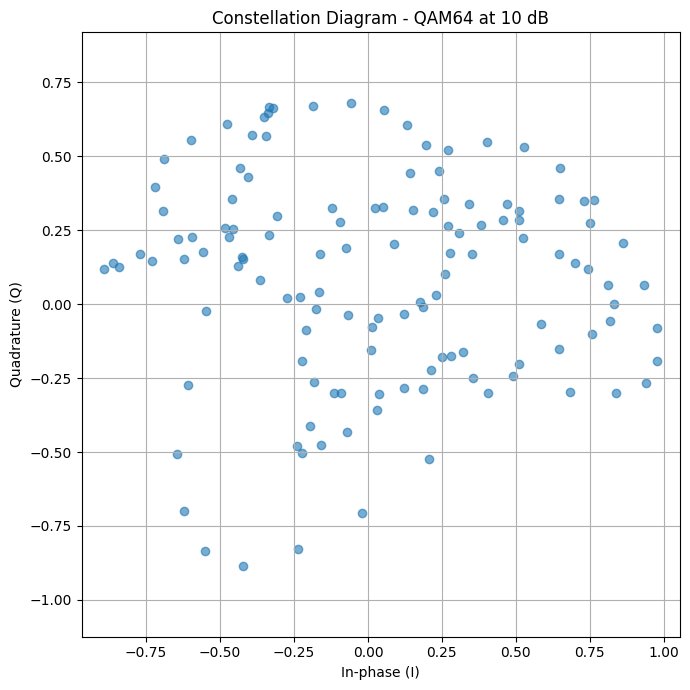

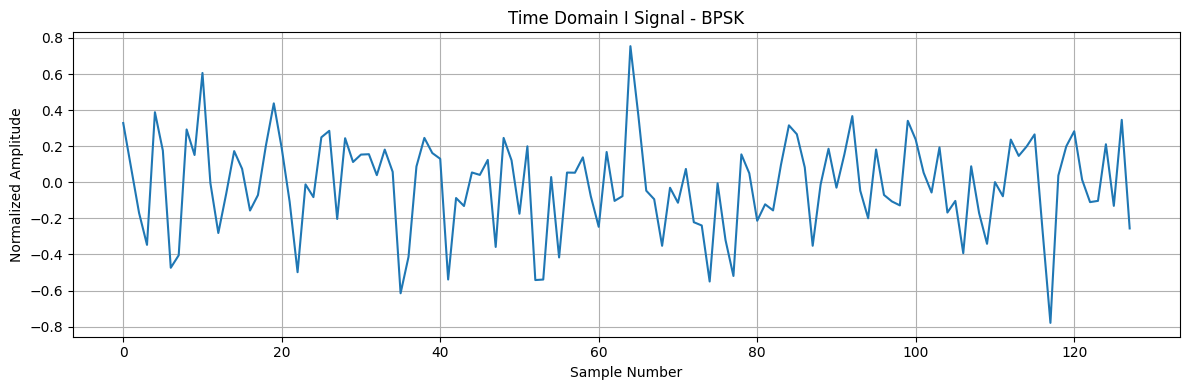

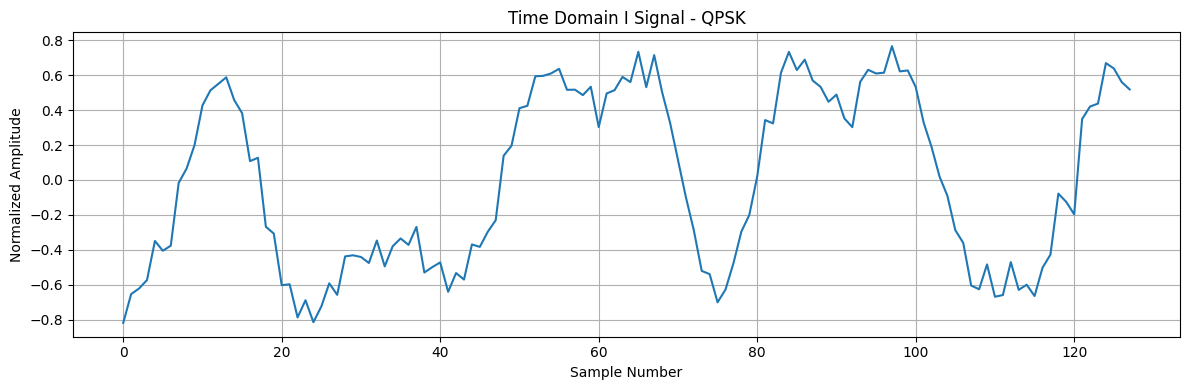

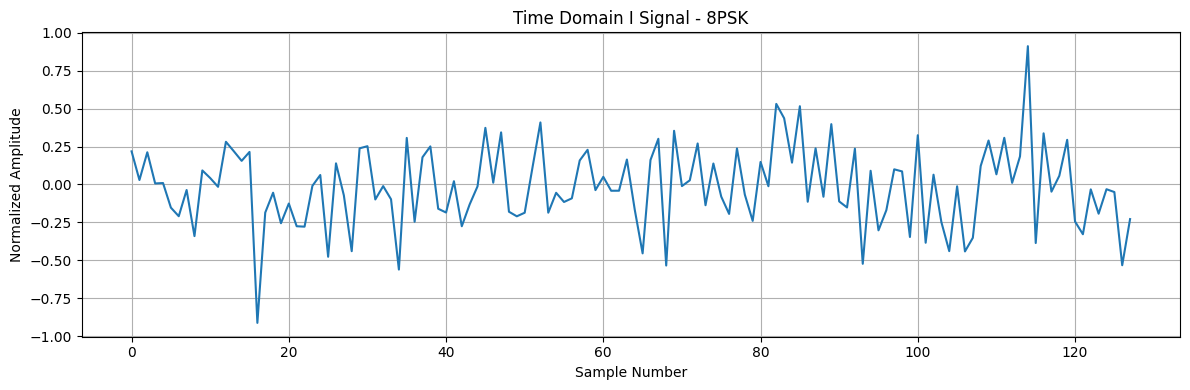

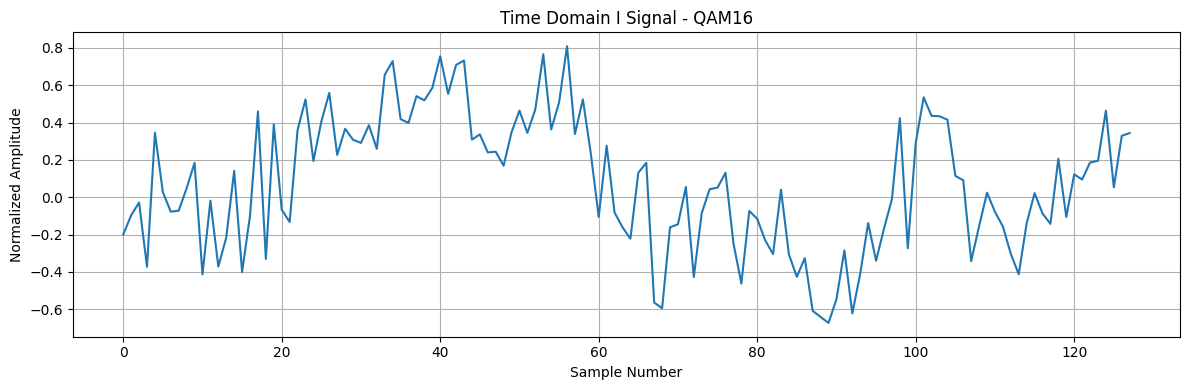

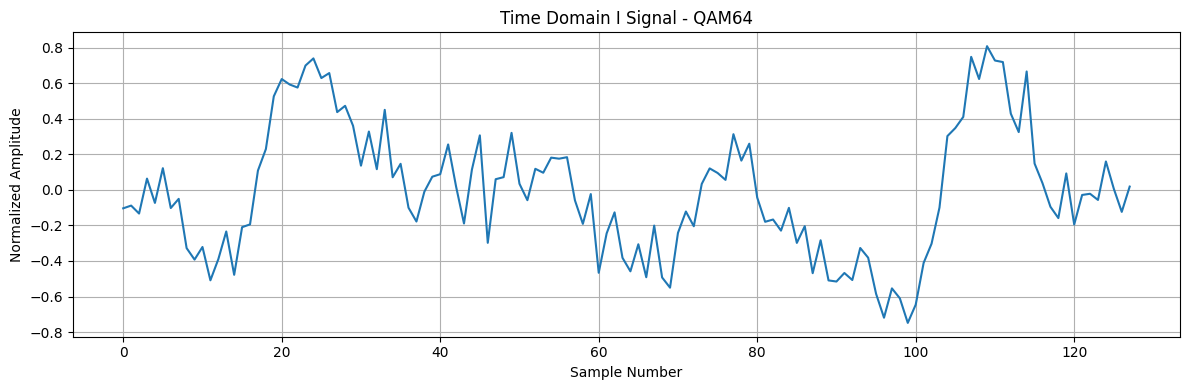


SIGNAL VISUALIZATION COMPLETED SUCCESSFULLY

Completed Visualizations:
[✓] Time Domain IQ Signal
[✓] In-phase Component
[✓] Quadrature Component
[✓] Constellation Diagram
[✓] FFT Frequency Spectrum
[✓] Spectrogram
[✓] Multiple Modulation Comparison
[✓] Time Domain Comparison

Signal visualization is ready for:
1. Project understanding
2. Seminar demonstration
3. CNN feature analysis
4. Final dashboard integration

NEXT STAGE: CNN MODEL DEVELOPMENT


In [1]:
# ============================================================
# AI Based Intelligent RF Spectrum Signal Identification System
# Notebook: 03_signal_visualization.ipynb
# Purpose: Visualize IQ Signals and Modulation Characteristics
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

print("=" * 70)
print("SIGNAL VISUALIZATION STARTED")
print("=" * 70)


# ============================================================
# 1. DEFINE DATA PATH
# ============================================================

processed_data_dir = "../data/processed"

if not os.path.exists(processed_data_dir):
    raise FileNotFoundError(
        f"Processed data directory not found:\n"
        f"{os.path.abspath(processed_data_dir)}"
    )

print("\nProcessed data directory found:")
print(os.path.abspath(processed_data_dir))


# ============================================================
# 2. LOAD PROCESSED DATA
# ============================================================

print("\nLoading processed data...")

X_train = np.load(
    os.path.join(processed_data_dir, "X_train.npy")
)

y_train = np.load(
    os.path.join(processed_data_dir, "y_train.npy")
)

snr_train = np.load(
    os.path.join(processed_data_dir, "snr_train.npy")
)

modulation_classes = np.load(
    os.path.join(processed_data_dir, "modulation_classes.npy")
)

print("Processed data loaded successfully!")

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("SNR shape:", snr_train.shape)

print("\nModulation Classes:")

for index, modulation in enumerate(modulation_classes):
    print(f"{index}: {modulation}")


# ============================================================
# 3. SELECT ONE SIGNAL FOR VISUALIZATION
# ============================================================

sample_index = 0

selected_signal = X_train[sample_index]

I = selected_signal[0]
Q = selected_signal[1]

selected_label = y_train[sample_index]
selected_modulation = modulation_classes[selected_label]

selected_snr = snr_train[sample_index]

sample_numbers = np.arange(len(I))

print("\n" + "=" * 70)
print("SELECTED SIGNAL")
print("=" * 70)

print("Sample Index:", sample_index)
print("Modulation Type:", selected_modulation)
print("SNR:", selected_snr, "dB")
print("Signal Shape:", selected_signal.shape)


# ============================================================
# 4. TIME DOMAIN IQ SIGNAL
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    sample_numbers,
    I,
    label="I - In-phase"
)

plt.plot(
    sample_numbers,
    Q,
    label="Q - Quadrature"
)

plt.title(
    f"Time Domain IQ Signal - "
    f"{selected_modulation} at {selected_snr} dB"
)

plt.xlabel("Sample Number")
plt.ylabel("Normalized Amplitude")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# ============================================================
# 5. I COMPONENT
# ============================================================

plt.figure(figsize=(12, 4))

plt.plot(I)

plt.title(
    f"In-phase (I) Component - "
    f"{selected_modulation}"
)

plt.xlabel("Sample Number")
plt.ylabel("Amplitude")

plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 6. Q COMPONENT
# ============================================================

plt.figure(figsize=(12, 4))

plt.plot(Q)

plt.title(
    f"Quadrature (Q) Component - "
    f"{selected_modulation}"
)

plt.xlabel("Sample Number")
plt.ylabel("Amplitude")

plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 7. CONSTELLATION DIAGRAM
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    I,
    Q,
    alpha=0.6
)

plt.title(
    f"Constellation Diagram - "
    f"{selected_modulation} at {selected_snr} dB"
)

plt.xlabel("In-phase (I)")
plt.ylabel("Quadrature (Q)")

plt.grid(True)
plt.axis("equal")

plt.tight_layout()
plt.show()


# ============================================================
# 8. CREATE COMPLEX IQ SIGNAL
# ============================================================

complex_signal = I + 1j * Q

print("\nComplex Signal Shape:", complex_signal.shape)


# ============================================================
# 9. FFT FREQUENCY SPECTRUM
# ============================================================

fft_result = np.fft.fft(complex_signal)

fft_shifted = np.fft.fftshift(fft_result)

frequency = np.fft.fftfreq(
    len(complex_signal)
)

frequency_shifted = np.fft.fftshift(
    frequency
)

magnitude_db = 20 * np.log10(
    np.abs(fft_shifted) + 1e-12
)

plt.figure(figsize=(12, 5))

plt.plot(
    frequency_shifted,
    magnitude_db
)

plt.title(
    f"FFT Frequency Spectrum - "
    f"{selected_modulation}"
)

plt.xlabel("Normalized Frequency")
plt.ylabel("Magnitude (dB)")

plt.grid(True)

plt.tight_layout()
plt.show()


# ============================================================
# 10. SPECTROGRAM
# ============================================================

frequencies, times, Sxx = signal.spectrogram(
    complex_signal,
    nperseg=32,
    noverlap=16
)

Sxx_db = 10 * np.log10(
    Sxx + 1e-12
)

plt.figure(figsize=(12, 6))

plt.pcolormesh(
    times,
    frequencies,
    Sxx_db,
    shading="gouraud"
)

plt.colorbar(
    label="Power / Frequency (dB)"
)

plt.title(
    f"Spectrogram - "
    f"{selected_modulation} at {selected_snr} dB"
)

plt.xlabel("Time")
plt.ylabel("Normalized Frequency")

plt.tight_layout()
plt.show()


# ============================================================
# 11. COMPARE DIFFERENT MODULATION TYPES
# ============================================================

print("\n" + "=" * 70)
print("MODULATION COMPARISON")
print("=" * 70)

# Select important modulation types for comparison
comparison_modulations = [
    "BPSK",
    "QPSK",
    "8PSK",
    "QAM16",
    "QAM64"
]

# Use SNR closest to 10 dB
target_snr = 10

available_classes = list(modulation_classes)

for modulation in comparison_modulations:

    if modulation not in available_classes:
        print(f"\nSkipping {modulation} - not found")
        continue

    modulation_index = available_classes.index(modulation)

    # Find signals of this modulation
    indices = np.where(
        y_train == modulation_index
    )[0]

    # Find signal closest to target SNR
    modulation_indices = indices[
        np.where(
            snr_train[indices] == target_snr
        )[0]
    ]

    if len(modulation_indices) == 0:

        # If exact 10 dB is not available,
        # use the first available signal
        sample_id = indices[0]

    else:

        sample_id = modulation_indices[0]

    comparison_signal = X_train[sample_id]

    comparison_I = comparison_signal[0]
    comparison_Q = comparison_signal[1]

    print(
        f"Displaying {modulation} "
        f"at SNR {snr_train[sample_id]} dB"
    )

    # Constellation
    plt.figure(figsize=(7, 7))

    plt.scatter(
        comparison_I,
        comparison_Q,
        alpha=0.6
    )

    plt.title(
        f"Constellation Diagram - "
        f"{modulation} "
        f"at {snr_train[sample_id]} dB"
    )

    plt.xlabel("In-phase (I)")
    plt.ylabel("Quadrature (Q)")

    plt.grid(True)
    plt.axis("equal")

    plt.tight_layout()
    plt.show()


# ============================================================
# 12. COMPARE TIME DOMAIN SIGNALS
# ============================================================

for modulation in comparison_modulations:

    if modulation not in available_classes:
        continue

    modulation_index = available_classes.index(modulation)

    indices = np.where(
        y_train == modulation_index
    )[0]

    sample_id = indices[0]

    comparison_signal = X_train[sample_id]

    comparison_I = comparison_signal[0]

    plt.figure(figsize=(12, 4))

    plt.plot(comparison_I)

    plt.title(
        f"Time Domain I Signal - {modulation}"
    )

    plt.xlabel("Sample Number")
    plt.ylabel("Normalized Amplitude")

    plt.grid(True)

    plt.tight_layout()
    plt.show()


# ============================================================
# 13. DATASET VISUALIZATION SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("SIGNAL VISUALIZATION COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nCompleted Visualizations:")

print("[✓] Time Domain IQ Signal")
print("[✓] In-phase Component")
print("[✓] Quadrature Component")
print("[✓] Constellation Diagram")
print("[✓] FFT Frequency Spectrum")
print("[✓] Spectrogram")
print("[✓] Multiple Modulation Comparison")
print("[✓] Time Domain Comparison")

print("\nSignal visualization is ready for:")
print("1. Project understanding")
print("2. Seminar demonstration")
print("3. CNN feature analysis")
print("4. Final dashboard integration")

print("\nNEXT STAGE: CNN MODEL DEVELOPMENT")